# **Random Forest Model: 9 Skin Lesion Classes**

This notebook trains and evaluates a tuned **Random Forest** classifier for a 9-class skin lesion classification task. The workflow uses image-derived tabular features, converts lesion labels into numeric classes, creates a stratified train/test split, engineers additional color and shape predictors, balances the training set with SMOTE, tunes a Random Forest model, and evaluates performance using both classification metrics and model-interpretability visualizations.

The added descriptions focus on two things:

1. **Data analysis:** understanding the dataset shape, class distribution, missing values, engineered features, train/test split, SMOTE balancing, model performance, and error patterns.
2. **Data visualizations:** explaining what each plot shows, how to read it, and why it matters for evaluating a 9-class skin lesion classifier.

The major visualizations are the confusion matrix, multiclass ROC curves, Random Forest feature importance, permutation importance, SHAP waterfall plot, SHAP class summary plots, SHAP global importance plot, SHAP force plot, and misclassification/error analysis.




---



### **Mount Google Drive and check project files**

This step connects the Colab notebook to Google Drive so the dataset and output folders can be accessed. The folder listing is a quick sanity check to confirm that the expected CAPSTONE PROJECT directory is available before the rest of the notebook runs.


In [ ]:
# STEP 0: Mounting Google Drive and quick check
from google.colab import drive
drive.mount('/content/drive')

!ls "/content/drive/MyDrive/CAPSTONE PROJECT"

Mounted at /content/drive
'9 CLASSES DATA SET'
'Capestone Posters'
'Capstone MAIN CODE '
'Code Documentation'
"CSV's with Images"
 DATA4381_Final_Report.gdoc
'Data 4382 - Deployment Presentation.gslides'
 DATA4382_PresentationOutline.gdoc
'DATA 4382 Progress Report.gdoc'
 DATA4382_TechnicalUpdate.gslides
 Dataloader.ipynb
"Diego's Clean Code"
'Final CAPSTONE report .gdoc'
 MobileNetV2_Baseline.ipynb
'Model Metrics Excel Sheet'
'old stuff'
 plots_3class_with_hair
'possible tableau layout.gdoc'
'PROGRESS & FINAL REPORTS'
'Progress Presentation Notes.gdoc'
'Proposal report.gdoc'
'Random Forest Models'
'Senior Design.gdoc'
'Skin Cancer Tabular Data'
 Skin_Images_SummaryData.csv
 Skin_Images_SummaryData.gsheet
 Skin_Test_Small
 Skin_Test_Small_Filtered
 Skin_Train_Small
 Skin_Train_Small_Filtered
'Tabular Data CSV'
 Test_Full
 TestFull_DR
'Tiffanys Github Code'
 Train_Full
 TrainFull_DR
'Whiteboard flowchart content .gdoc'
 xgb_3class_with_hair_results.csv
'XG boost'
 xgb_results_3class_wit

### **Import general Python libraries**

This cell imports the core libraries used throughout the notebook. pandas and numpy handle data processing, while matplotlib and seaborn are used for visualizations. The warning filter keeps the notebook output cleaner.


In [ ]:
# STEP 1: Import necessary libraries
import os
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **Import machine learning tools**

This cell imports the scikit-learn tools needed for model training, tuning, evaluation, and interpretation. The notebook uses stratified splitting and cross-validation, a preprocessing pipeline, RandomizedSearchCV for hyperparameter tuning, classification metrics, ROC/precision-recall tools, and permutation importance.


In [ ]:
# Importing specific tools from scikit-learn for machine learning tasks.
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
from sklearn.preprocessing import label_binarize
from sklearn.inspection import permutation_importance

### **Set reproducibility options and results folder**

A fixed random seed makes the data split, SMOTE sampling, and Random Forest training more reproducible. The target column is defined as label, and the results folder is created so plots, CSV files, and model outputs can be saved in one location.


In [ ]:
# STEP 2: Important Settings + Results Folder Configuration

# `SEED` is a fixed value used for reproducibility of random operations.
# Setting a seed ensures that random processes (like data splitting or model initialization) produce the same results each time.
SEED = 42
# `TARGET_COL` defines the name of the column that contains the target variable (the labels to be predicted).
TARGET_COL = "label"

# `RESULTS_DIR` specifies the path where all generated plots and CSV files will be saved.
# `os.makedirs(RESULTS_DIR, exist_ok=True)` creates the directory if it doesn't already exist,
# preventing errors if the folder is missing.
RESULTS_DIR = "/content/drive/MyDrive/CAPSTONE PROJECT/Random Forest Models"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Setting random seeds for `numpy` and `random` libraries to ensure reproducibility across different runs.
np.random.seed(SEED)
random.seed(SEED)

print("Setup done.")
print("Results will save to:", RESULTS_DIR)

Setup done.
Results will save to: /content/drive/MyDrive/CAPSTONE PROJECT/Random Forest Models


## **Load the 9-class dataset**

The dataset is loaded from Google Drive into a pandas DataFrame. This first analysis step checks the number of rows and columns, counts how many examples belong to each lesion class, confirms whether there are missing values, and previews the first few records.

These checks are important because they describe the starting condition of the modeling problem. The class counts show whether the target variable is balanced, the null check shows whether imputation or cleaning may be needed, and the preview confirms that the file contains the expected image-derived numeric features.


In [ ]:
#STEP 3: Load the CSV + sanity check

CSV_PATH = "/content/drive/MyDrive/CAPSTONE PROJECT/9 CLASSES DATA SET/SC_Dataset_9_Classes.csv"

df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
print("\nLabel counts:")
print(df[TARGET_COL].value_counts())

print("\nAny nulls?", df.isnull().sum().sum())

display(df.head(3))

Shape: (2357, 131)

Label counts:
label
pigmented benign keratosis    478
melanoma                      454
basal cell carcinoma          392
nevus                         373
squamous cell carcinoma       197
vascular lesion               142
actinic keratosis             130
dermatofibroma                111
seborrheic keratosis           80
Name: count, dtype: int64

Any nulls? 0


,avg_r,avg_g,avg_b,hist_feature_0,hist_feature_1,hist_feature_2,hist_feature_3,hist_feature_4,hist_feature_5,hist_feature_6,...,sobel_r,sobel_g,sobel_b,min_enc_circle_radius,min_enc_circle_area,min_area_rect_width,min_area_rect_height,min_area_rect_aspect_ratio,min_area_rect_angle,label
0,215.435722,154.768741,160.486663,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,16.298068,15.719409,23.341190,374.30011,440138.928524,449.0,599.0,0.749583,-90.0,vascular lesion
1,203.781219,179.247785,208.150415,0.0,0.0,0.0,0.0,1.0,2.0,4.0,...,14.113285,14.688772,13.842412,374.30011,440138.928524,449.0,599.0,0.749583,-90.0,vascular lesion
2,195.706115,120.804822,142.253215,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,16.913575,18.003877,23.534902,374.30011,440138.928524,449.0,599.0,0.749583,-90.0,vascular lesion


### **Dataset analysis summary**

The dataset contains **2,357 rows** and **131 columns**, including the target label. Each row represents one lesion example described by tabular features extracted from image information, such as average color channels, histogram values, texture measurements, edge features, and shape features.

The class distribution is imbalanced. The largest class is **pigmented benign keratosis** with **478 examples**, while the smallest class is **seborrheic keratosis** with **80 examples**. This means the model would see far more examples from some classes than others if the raw training data were used directly.

This imbalance affects model evaluation because accuracy alone can look acceptable even when minority classes perform poorly. For that reason, later steps use a stratified split, SMOTE balancing, macro F1 scoring, and class-level metrics instead of relying only on overall accuracy.


### **Encode text labels as numeric classes**

Machine learning models require numeric target values, so each skin lesion class name is mapped to an integer from 0 to 8. The CLASS_NAMES list stores the original class names in the same order, which is later used to label confusion matrices, ROC curves, SHAP plots, and reports.


In [ ]:
# STEP 4: Encode labels (text to numbers)

#mapping each class name to a number
label_map = {
    "pigmented benign keratosis" : 0,
    "melanoma"                   : 1,
    "basal cell carcinoma"       : 2,
    "nevus"                      : 3,
    "squamous cell carcinoma"    : 4,
    "vascular lesion"            : 5,
    "actinic keratosis"          : 6,
    "dermatofibroma"             : 7,
    "seborrheic keratosis"       : 8
}

#apply the mapping
df[TARGET_COL] = df[TARGET_COL].map(label_map).astype(int)

#class names in order (we'll use this for plots later)
CLASS_NAMES = list(label_map.keys())

print("Label encoding done.")
print("\nEncoded label counts:")
print(df[TARGET_COL].value_counts().sort_index())
print("\nClass names:", CLASS_NAMES)

Label encoding done.

Encoded label counts:
label
0    478
1    454
2    392
3    373
4    197
5    142
6    130
7    111
8     80
Name: count, dtype: int64

Class names: ['pigmented benign keratosis', 'melanoma', 'basal cell carcinoma', 'nevus', 'squamous cell carcinoma', 'vascular lesion', 'actinic keratosis', 'dermatofibroma', 'seborrheic keratosis']


### **Create a stratified 80/20 train/test split**

The feature matrix X contains all columns except the target label, while y contains the encoded lesion labels. The data is split into training and testing sets using an 80/20 split.

Stratification is used so that every lesion class keeps approximately the same proportion in both the training and test sets. This is especially important for this dataset because the class counts are uneven. Without stratification, a minority class such as seborrheic keratosis could be underrepresented in the test set, making the evaluation less reliable.


In [ ]:
#STEP 5: Stratified 80/20 Train/Test Split

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,          #this ensures all 9 classes are represented in both train and test
    random_state=SEED
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

print("\nTrain label counts:")
print(y_train.value_counts().sort_index())

print("\nTest label counts:")
print(y_test.value_counts().sort_index())

Train size: (1885, 130)
Test size : (472, 130)

Train label counts:
label
0    382
1    363
2    313
3    298
4    158
5    114
6    104
7     89
8     64
Name: count, dtype: int64

Test label counts:
label
0    96
1    91
2    79
3    75
4    39
5    28
6    26
7    22
8    16
Name: count, dtype: int64


### **Train/test split analysis**

The training set contains **1,885 examples**, and the test set contains **472 examples**. Because stratification was used, all 9 classes appear in both sets with similar proportions to the original dataset.

The training split is used for feature engineering, SMOTE balancing, cross-validation, hyperparameter tuning, and model fitting. The test split is kept separate until final evaluation so it can estimate how well the model performs on unseen data.


### **Engineer color ratio features**

This step creates new variables that compare the average red, green, and blue channel values. Ratios such as ratio_rg, ratio_rb, and ratio_gb capture relative color dominance rather than raw color intensity.

These features may help the model distinguish lesion types that have similar brightness but different color balance. For example, two lesions could have comparable average intensity while still differing in how much red or blue is present relative to the other channels.


In [ ]:
#STEP 6A: Channel Ratio Features
#dividing channels to capture color dominance between R, G, B

X_train["ratio_rg"] = X_train["avg_r"] / (X_train["avg_g"] + 1e-6)
X_train["ratio_rb"] = X_train["avg_r"] / (X_train["avg_b"] + 1e-6)
X_train["ratio_gb"] = X_train["avg_g"] / (X_train["avg_b"] + 1e-6)

X_test["ratio_rg"] = X_test["avg_r"] / (X_test["avg_g"] + 1e-6)
X_test["ratio_rb"] = X_test["avg_r"] / (X_test["avg_b"] + 1e-6)
X_test["ratio_gb"] = X_test["avg_g"] / (X_test["avg_b"] + 1e-6)

print("Channel ratio features added.")
print("New shape:", X_train.shape)

Channel ratio features added.
New shape: (1885, 133)


### **Engineer color contrast features**

Color contrast features subtract one average color channel from another. These variables measure how different the RGB channels are from each other, which can represent color contrast or color irregularity within the lesion image.

These features add another way to summarize visual color differences. While ratios describe proportional relationships, contrast features describe absolute differences between channels.


In [ ]:
#STEP 6B: Color Contrast Features
#subtracting channels to capture how different the colors are from each other

X_train["contrast_rg"] = X_train["avg_r"] - X_train["avg_g"]
X_train["contrast_rb"] = X_train["avg_r"] - X_train["avg_b"]
X_train["contrast_gb"] = X_train["avg_g"] - X_train["avg_b"]

X_test["contrast_rg"] = X_test["avg_r"] - X_test["avg_g"]
X_test["contrast_rb"] = X_test["avg_r"] - X_test["avg_b"]
X_test["contrast_gb"] = X_test["avg_g"] - X_test["avg_b"]

print("Color contrast features added.")
print("New shape:", X_train.shape)

Color contrast features added.
New shape: (1885, 136)


### **Engineer color moment features**

This step summarizes overall color behavior using brightness, color_range, and color_std. Brightness captures the average intensity across RGB channels, while color range and color standard deviation describe how spread out the color channels are.

These features are useful because lesion classes may differ not only in individual colors, but also in overall intensity and color variability. Higher color variation may indicate more diverse visual patterns, while lower variation may indicate more uniform coloring.


In [ ]:
#STEP 6C: Color Moment Features
#overall brightness, color range, and color variation across R, G, B

X_train["brightness"]  = (X_train["avg_r"] + X_train["avg_g"] + X_train["avg_b"]) / 3
X_train["color_range"] = X_train[["avg_r","avg_g","avg_b"]].max(axis=1) - X_train[["avg_r","avg_g","avg_b"]].min(axis=1)
X_train["color_std"]   = X_train[["avg_r","avg_g","avg_b"]].std(axis=1)

X_test["brightness"]  = (X_test["avg_r"] + X_test["avg_g"] + X_test["avg_b"]) / 3
X_test["color_range"] = X_test[["avg_r","avg_g","avg_b"]].max(axis=1) - X_test[["avg_r","avg_g","avg_b"]].min(axis=1)
X_test["color_std"]   = X_test[["avg_r","avg_g","avg_b"]].std(axis=1)

print("Color moment features added.")
print("New shape:", X_train.shape)

Color moment features added.
New shape: (1885, 139)


### **Engineer ABCD-inspired shape features**

These features are inspired by dermatology image-analysis concepts such as asymmetry, border irregularity, and diameter. They are calculated from existing rectangle and enclosing-circle measurements.

The goal is to give the model more interpretable shape information. asymmetry_ratio compares width and height, border_irregularity compares enclosing-circle area with rectangle area, and diameter_estimate approximates lesion size using rectangle dimensions.


In [ ]:
#STEP 6D: ABCD Shape Features
#asymmetry, border irregularity, and diameter estimate from existing shape columns

X_train["asymmetry_ratio"]     = X_train["min_area_rect_width"] / (X_train["min_area_rect_height"] + 1e-6)
X_train["border_irregularity"] = X_train["min_enc_circle_area"] / (X_train["min_area_rect_width"] * X_train["min_area_rect_height"] + 1e-6)
X_train["diameter_estimate"]   = (X_train["min_area_rect_width"] + X_train["min_area_rect_height"]) / 2

X_test["asymmetry_ratio"]     = X_test["min_area_rect_width"] / (X_test["min_area_rect_height"] + 1e-6)
X_test["border_irregularity"] = X_test["min_enc_circle_area"] / (X_test["min_area_rect_width"] * X_test["min_area_rect_height"] + 1e-6)
X_test["diameter_estimate"]   = (X_test["min_area_rect_width"] + X_test["min_area_rect_height"]) / 2

print("ABCD shape features added.")
print("New shape:", X_train.shape)

ABCD shape features added.
New shape: (1885, 142)


### **Review the engineered feature set**

This cell lists all newly created features and reports the updated feature count. The analysis confirms that **12 engineered features** were added and that the training data now has **142 total features**.

This checkpoint matters because engineered features must be added consistently to both the training and testing data. If the train and test feature columns do not match, the model cannot be evaluated correctly.


In [ ]:
#STEP 6E: Summary of all new engineered features

new_features = [
    "ratio_rg", "ratio_rb", "ratio_gb",
    "contrast_rg", "contrast_rb", "contrast_gb",
    "brightness", "color_range", "color_std",
    "asymmetry_ratio", "border_irregularity",
    "diameter_estimate"
]

print("Total new features added:", len(new_features))
print("Total feature count now:", X_train.shape[1])
print("\nNew features:", new_features)

Total new features added: 12
Total feature count now: 142

New features: ['ratio_rg', 'ratio_rb', 'ratio_gb', 'contrast_rg', 'contrast_rb', 'contrast_gb', 'brightness', 'color_range', 'color_std', 'asymmetry_ratio', 'border_irregularity', 'diameter_estimate']


### **Apply SMOTE to the training data only**

SMOTE creates synthetic examples for minority classes so the Random Forest sees a more balanced training set. It is applied only to the training data, not the test data, to avoid data leakage.

The before-and-after class counts are an important data-analysis checkpoint. They show how imbalanced the training data was before resampling and verify that the resampled training set contains equal representation across all 9 classes.


In [ ]:
#STEP 7: Applying SMOTE on training data only

from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(y_train.value_counts().sort_index())

smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts().sort_index())

print("\nX_train shape after SMOTE:", X_train_sm.shape)

Before SMOTE:
label
0    382
1    363
2    313
3    298
4    158
5    114
6    104
7     89
8     64
Name: count, dtype: int64

After SMOTE:
label
0    382
1    382
2    382
3    382
4    382
5    382
6    382
7    382
8    382
Name: count, dtype: int64

X_train shape after SMOTE: (3438, 142)


### **SMOTE analysis summary**

Before SMOTE, the training classes ranged from **382 examples** in the largest class to **64 examples** in the smallest class. After SMOTE, every class has **382 training examples**, producing a balanced training set with **3,438 rows**.

This balancing step helps the model pay more attention to minority classes during training. However, the test set remains unchanged, so the final evaluation still reflects the original real-world class imbalance.


### **Build the Random Forest pipeline**

The pipeline first imputes missing values using the median, then fits a Random Forest classifier. Even though the dataset initially reports no missing values, keeping the imputer in the pipeline makes the model workflow more robust.


In [ ]:
#STEP 8:Random Forest Pipeline

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(
        n_estimators=200,
        random_state=SEED,
        n_jobs=-1
    ))
])

print("Pipeline ready.")
print(pipe)

Pipeline ready.
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('rf',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])


### **Tune Random Forest hyperparameters**

RandomizedSearchCV tests multiple Random Forest settings using 5-fold stratified cross-validation. The search compares different numbers of trees, tree depths, minimum split sizes, minimum leaf sizes, and feature-selection strategies at each split.

The scoring metric is **macro F1**, which gives equal weight to all classes. This is more appropriate than accuracy for this problem because the dataset is imbalanced and minority-class performance matters.


In [ ]:
#STEP 9: Hyperparameter Tuning with RandomizedSearchCV

param_dist = {
    "rf__n_estimators":      [100, 200, 300, 400, 500], # Number of trees
    "rf__max_depth":         [None, 10, 20, 30],       # Maximum depth of the tree (None means full depth)
    "rf__min_samples_split": [2, 5, 10],               # Minimum samples required to split an internal node
    "rf__min_samples_leaf":  [1, 2, 4],                # Minimum samples required to be at a leaf node
    "rf__max_features":      ['sqrt', 'log2']          # Number of features to consider at each split
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring="f1_macro",
    n_jobs=-1,
    cv=cv,
    verbose=1,
    random_state=SEED
)

#training on SMOTE'd training data
search.fit(X_train_sm, y_train_sm)

print("\nBEST PARAMETERS:")
print(json.dumps(search.best_params_, indent=2))

print("\nBest CV F1 macro:", round(search.best_score_, 4))

best_model = search.best_estimator_

Fitting 5 folds for each of 40 candidates, totalling 200 fits

BEST PARAMETERS:
{
  "rf__n_estimators": 300,
  "rf__min_samples_split": 2,
  "rf__min_samples_leaf": 1,
  "rf__max_features": "sqrt",
  "rf__max_depth": 30
}

Best CV F1 macro: 0.7721


### **Tuning result analysis**

The best cross-validation macro F1 score is **0.7721**. The selected Random Forest uses **300 trees**, a maximum depth of **30**, sqrt feature selection at each split, a minimum split size of **2**, and a minimum leaf size of **1**.

This cross-validation score reflects performance during training on the SMOTE-balanced data. It should be compared with the final test-set results because test performance is usually lower and gives a better estimate of how the model generalizes to unseen examples.


### **Evaluate the tuned model on the test set**

The tuned model is evaluated on the untouched test set. The notebook calculates predicted labels, predicted class probabilities, test accuracy, and a full classification report.

The classification report is one of the most important data-analysis outputs because it shows precision, recall, and F1-score separately for each lesion class. This makes it possible to see which classes the model handles well and which classes still need improvement.


In [ ]:
#STEP 10: Evaluating on test set

y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)

print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))

print("\nClassification Report (9-class Random Forest):")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))

Test Accuracy: 0.5953

Classification Report (9-class Random Forest):
                            precision    recall  f1-score   support

pigmented benign keratosis       0.77      0.76      0.76        96
                  melanoma       0.67      0.66      0.67        91
      basal cell carcinoma       0.59      0.70      0.64        79
                     nevus       0.62      0.61      0.62        75
   squamous cell carcinoma       0.39      0.33      0.36        39
           vascular lesion       0.73      0.68      0.70        28
         actinic keratosis       0.24      0.27      0.25        26
            dermatofibroma       0.50      0.36      0.42        22
      seborrheic keratosis       0.00      0.00      0.00        16

                  accuracy                           0.60       472
                 macro avg       0.50      0.49      0.49       472
              weighted avg       0.60      0.60      0.59       472



### **Test-set performance analysis**

The tuned Random Forest reaches a test accuracy of **0.5953**, meaning it predicts about 60% of the test examples correctly. The weighted F1-score is **0.59**, while the macro F1-score is **0.49**.

The gap between weighted and macro averages is important. The weighted score gives more influence to larger classes, while the macro score treats all classes equally. The lower macro score shows that the model performs less consistently across minority classes.

Class-level results show stronger performance for classes such as pigmented benign keratosis, melanoma, basal cell carcinoma, nevus, and vascular lesion. Performance is weaker for squamous cell carcinoma, actinic keratosis, dermatofibroma, and especially seborrheic keratosis, which receives an F1-score of **0.00** in this test run. This suggests the model struggles most with the smallest or most visually overlapping classes.


## **Confusion matrix**

The confusion matrix visualizes the relationship between the true class labels and the model's predicted labels. Rows represent the actual lesion classes, while columns represent the predicted classes.

Values on the diagonal are correct predictions. Values off the diagonal are mistakes. Large off-diagonal values show which classes the model commonly confuses with one another.

This visualization is useful because overall accuracy does not show where the model is making errors. For a medical image-classification task, identifying specific confusion patterns is especially important because some types of mistakes may be more concerning than others.


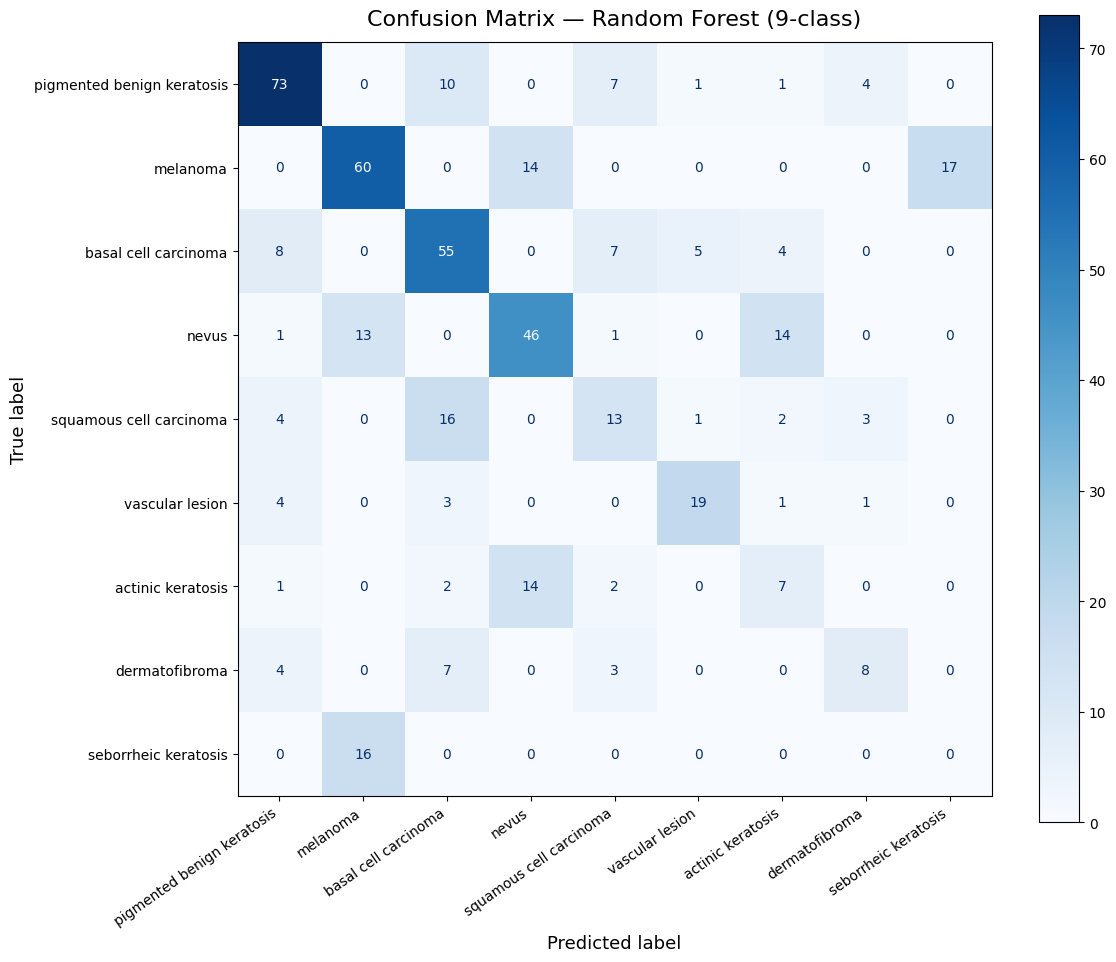

Saved confusion matrix.


In [ ]:
#STEP 11: Confusion Matrix

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred, labels=list(range(9))),
    display_labels=CLASS_NAMES
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

ax.set_title("Confusion Matrix — Random Forest (9-class)", fontsize=16, pad=12)
ax.set_xlabel("Predicted label", fontsize=13)
ax.set_ylabel("True label", fontsize=13)

plt.setp(ax.get_xticklabels(), rotation=35, ha="right", fontsize=10)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "confusion_matrix_9class.png"), dpi=150)
plt.show()

print("Saved confusion matrix.")

### **Confusion Matrix Analysis**
The confusion matrix shows that the Random Forest model correctly classified **281 out of 472 test images**, or about **59.5%** accuracy. The model performed best on larger classes such as pigmented benign keratosis, melanoma, and basal cell carcinoma, with **73, 60, and 55** correct predictions respectively. However, it struggled more with smaller or visually similar classes, especially **seborrheic keratosis, where it made 0 correct predictions** and classified all 16 true cases as melanoma.

The main errors show that the model often confused visually similar lesion types. For melanoma, there were **31 false negatives****, including 17 cases predicted as seborrheic keratosis** and **14 predicted as nevus**. This is important because false negatives for melanoma mean the model missed true melanoma cases. The model also confused **squamous cell carcinoma with basal cell carcinoma 16 times**, suggesting that these cancer-related classes shared similar features. Another major pattern was confusion between nevus and actinic keratosis, with errors in both directions.

Overall, the confusion matrix suggests that the model learned useful patterns from the data but still had difficulty separating some lesion classes. The most concerning issue is the melanoma false negatives, while the weakest class performance was seborrheic keratosis. These results suggest that future improvements should focus on reducing confusion between melanoma, nevus, and seborrheic keratosis, as well as improving performance on minority classes.


---



### **Multiclass ROC-AUC curves**

The ROC visualization uses a one-vs-rest approach, drawing one curve for each lesion class. For each class, the model treats that class as the positive class and all other classes as the negative group.

A curve closer to the upper-left corner indicates better separation between that class and the rest of the data. The diagonal dashed line represents random guessing. The macro ROC-AUC averages performance across all classes, giving each class equal weight.

In this notebook, the macro ROC-AUC is **0.8846**, which suggests the model often assigns useful probability rankings even though the final class predictions still show weaker performance for some classes.

ROC-AUC macro (OvR): 0.8846


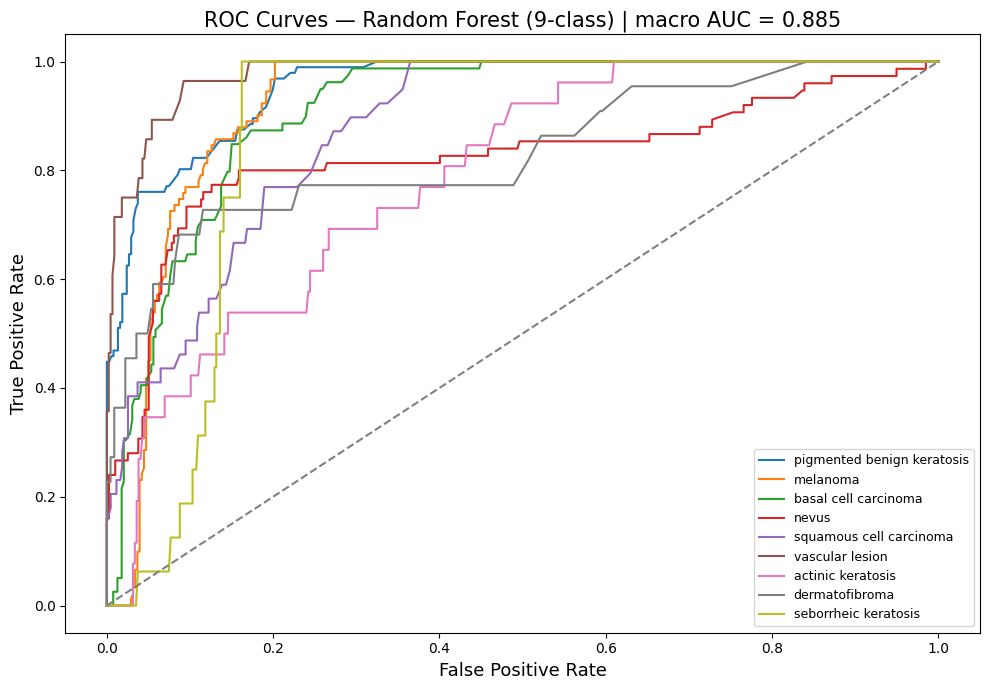

Saved ROC curves.


In [ ]:
#STEP 12: ROC-AUC Curves

y_test_bin = label_binarize(y_test, classes=list(range(9)))

auc_macro = roc_auc_score(
    y_test_bin,
    y_proba,
    average="macro",
    multi_class="ovr"
)

print("ROC-AUC macro (OvR):", round(auc_macro, 4))

plt.figure(figsize=(10, 7))

for i, cname in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, label=cname)

plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.title(f"ROC Curves — Random Forest (9-class) | macro AUC = {auc_macro:.3f}", fontsize=15)
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "roc_curves_9class.png"), dpi=150)
plt.show()

print("Saved ROC curves.")

#### **ROC Analysis**

The ROC curve shows that the Random Forest model had strong overall class-separation ability, with a macro AUC of 0.885. This means the model was generally good at assigning higher prediction probabilities to the correct class compared with the other classes. Several curves rise quickly toward the top-left corner, showing strong performance for classes such as vascular lesion, seborrheic keratosis, pigmented benign keratosis, and melanoma. However, some classes, such as actinic keratosis, nevus, and dermatofibroma, have curves that stay farther from the top-left corner, meaning the model had more difficulty separating those classes from the rest. Overall, the ROC-AUC suggests the model can rank class probabilities well, even though the confusion matrix shows it still makes classification mistakes when choosing the final predicted label.


---



### **Random Forest feature importance visualization**

This horizontal bar chart shows the top 30 features according to the Random Forest model's built-in impurity-based importance values. Larger bars indicate features that contributed more to reducing impurity across the decision trees.

The top features include several shape-related variables, such as min_area_rect_aspect_ratio, asymmetry_ratio, min_enc_circle_area, min_enc_circle_radius, and diameter_estimate. This suggests that lesion shape information was important for the model.



Top 20 features by Random Forest impurity-based importance:


,feature,importance
0,min_area_rect_aspect_ratio,0.018884
1,asymmetry_ratio,0.016828
2,min_enc_circle_area,0.016751
3,min_enc_circle_radius,0.016085
4,diameter_estimate,0.015941
5,min_area_rect_height,0.015416
6,laplacian_r,0.014533
7,min_area_rect_width,0.014028
8,laplacian_b,0.013202
9,border_irregularity,0.013134


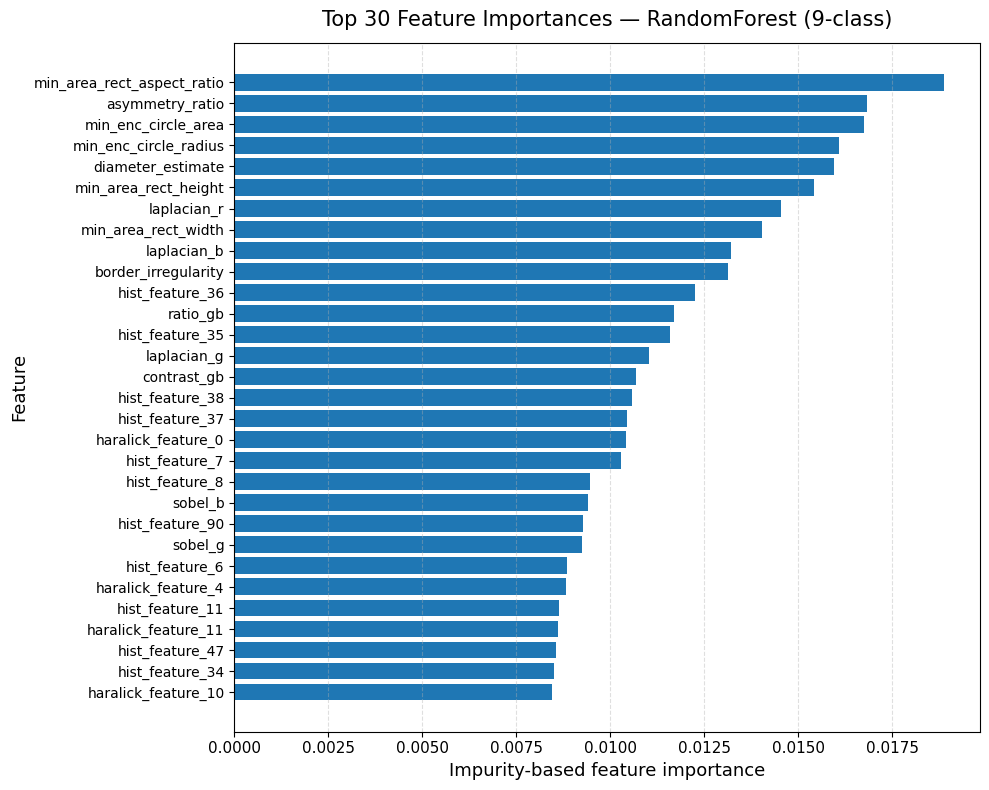

Saved feature importance plot.


In [ ]:
#STEP 13: Random Forest Feature Importance (top 30)

# Corrected: Access the RandomForestClassifier step named 'rf'
rf_model    = best_model.named_steps["rf"]
feature_names = X_train_sm.columns.tolist()

# Use the Random Forest model's built-in impurity-based feature_importances_ values.
imp_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance"   : rf_model.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 features by Random Forest impurity-based importance:")
display(imp_df.head(20))

#plotting top 30
top_30 = imp_df.head(30).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(top_30["feature"], top_30["importance"], color="#1f77b4")
plt.xlabel("Impurity-based feature importance", fontsize=13)
plt.ylabel("Feature", fontsize=13)
plt.title("Top 30 Feature Importances — RandomForest (9-class)", fontsize=15, pad=12)
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.xticks(fontsize=11)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "rf_feature_importance_9class.png"), dpi=150)
plt.show()

print("Saved feature importance plot.")

#### **Feature Importance Analysis**
The Random Forest feature importance plot shows that the model relied most on shape and size-based features when making predictions. The top features were min_area_rect_aspect_ratio, asymmetry_ratio, min_enc_circle_area, min_enc_circle_radius, diameter_estimate, and min_area_rect_height, which describe the lesion’s geometry, size, and irregularity. This means the model found differences in lesion shape and structure especially useful for separating the nine classes. Texture and color-related features, such as laplacian_r, laplacian_b, border_irregularity, histogram features, Sobel features, and Haralick features, were also important. Overall, this plot suggests that the Random Forest model made decisions using a combination of lesion shape, asymmetry, border irregularity, edge patterns, texture, and color information, with geometric features having the strongest influence.


---



## **Permutation importance visualization**

Permutation importance measures how much the model's macro F1 score decreases when one feature is randomly shuffled. If shuffling a feature causes a large performance drop, the model depends on that feature for accurate predictions.

This plot shows the top 30 features by mean decrease in macro F1, with error bars showing variability across repeated shuffles. Unlike impurity-based feature importance, permutation importance is based on the model's actual test-set performance.

In this notebook, several histogram and edge-related features appear near the top, which suggests that texture, color distribution, and boundary information may contribute strongly to prediction performance.


Top 10 features by permutation importance:


,feature,pi_mean,pi_std
0,hist_feature_3,0.006727,0.002282
1,hist_feature_38,0.006654,0.005589
2,hist_feature_41,0.005852,0.002302
3,hist_feature_30,0.005558,0.001699
4,hist_feature_60,0.005506,0.001923
5,hist_feature_56,0.005322,0.004584
6,hist_feature_18,0.005142,0.002867
7,sobel_g,0.005125,0.002469
8,hist_feature_65,0.004444,0.003332
9,hist_feature_46,0.004092,0.002675


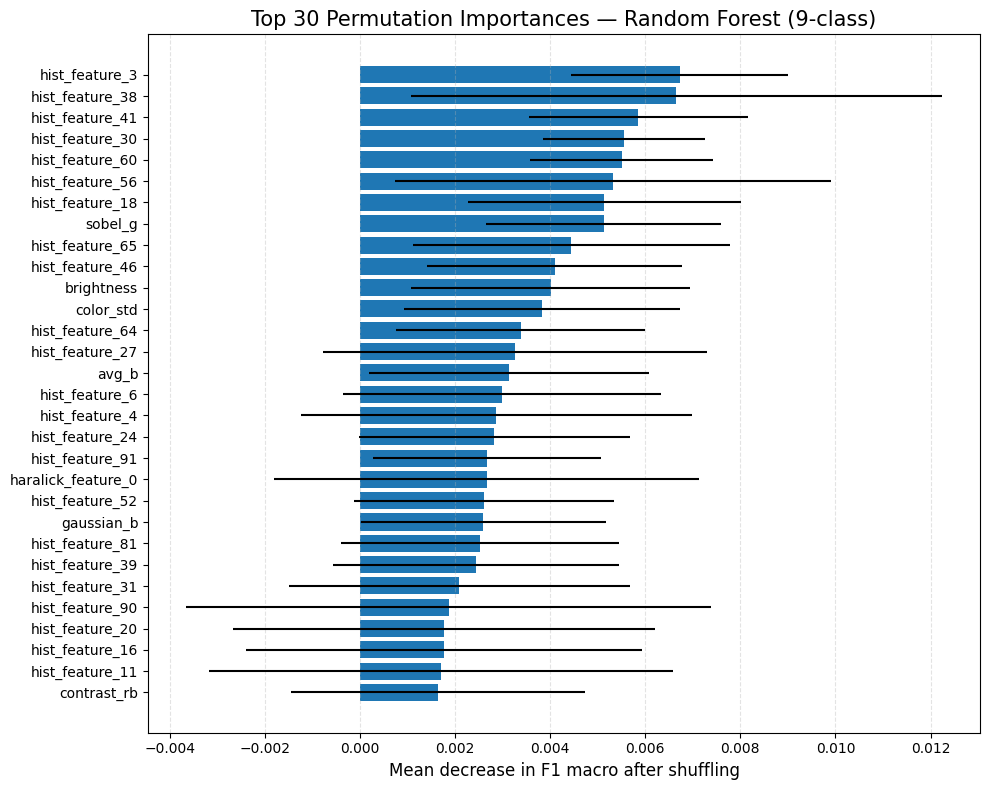

Saved permutation importance plot.


In [ ]:
#STEP 14: Permutation Importance

PI_DIR = os.path.join(RESULTS_DIR, "permutation_importance")
os.makedirs(PI_DIR, exist_ok=True)

pi = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=10,
    random_state=SEED,
    n_jobs=-1
)

pi_df = pd.DataFrame({
    "feature": X_test.columns,
    "pi_mean": pi.importances_mean,
    "pi_std" : pi.importances_std
}).sort_values("pi_mean", ascending=False).reset_index(drop=True)

#save full ranking
pi_df.to_csv(os.path.join(PI_DIR, "permutation_importance_full.csv"), index=False)

print("Top 10 features by permutation importance:")
display(pi_df.head(10))

#plot top 30
top_30 = pi_df.head(30).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(top_30["feature"], top_30["pi_mean"], xerr=top_30["pi_std"])
plt.xlabel("Mean decrease in F1 macro after shuffling", fontsize=12)
plt.title("Top 30 Permutation Importances — Random Forest (9-class)", fontsize=15)
plt.grid(axis="x", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig(os.path.join(PI_DIR, "permutation_importance_top30.png"), dpi=150)
plt.show()

print("Saved permutation importance plot.")

### **SHAP waterfall plot for one prediction**

The SHAP waterfall plot explains one individual prediction. It starts from the model's baseline expected output for the predicted class and then shows which features push the prediction higher or lower.

The SHAP waterfall plot explains one individual prediction, where the model predicted basal cell carcinoma for instance **327**. The model started from a **baseline prediction value of 0.111** and increased to a final prediction value of **0.493 for basal cell carcinoma**. Most of the important features pushed the prediction upward, meaning they increased the model’s confidence in this class. The strongest individual contributors included **laplacian_r, laplacian_b, sobel_b, ratio_rg, and laplacian_g, which are mainly color, edge, and texture-related features**. Shape-related features such as **min_enc_circle_radius, min_enc_circle_area, diameter_estimate, min_area_rect_height, and min_area_rect_aspect_ratio** also supported the prediction. Overall, this plot shows that for this specific image, the model predicted basal cell carcinoma because a combination of texture, color contrast, edge patterns, and lesion shape features all pushed the prediction score higher.


Displaying SHAP waterfall plot for instance index: 327
True label for this instance: basal cell carcinoma
Predicted label for this instance: basal cell carcinoma


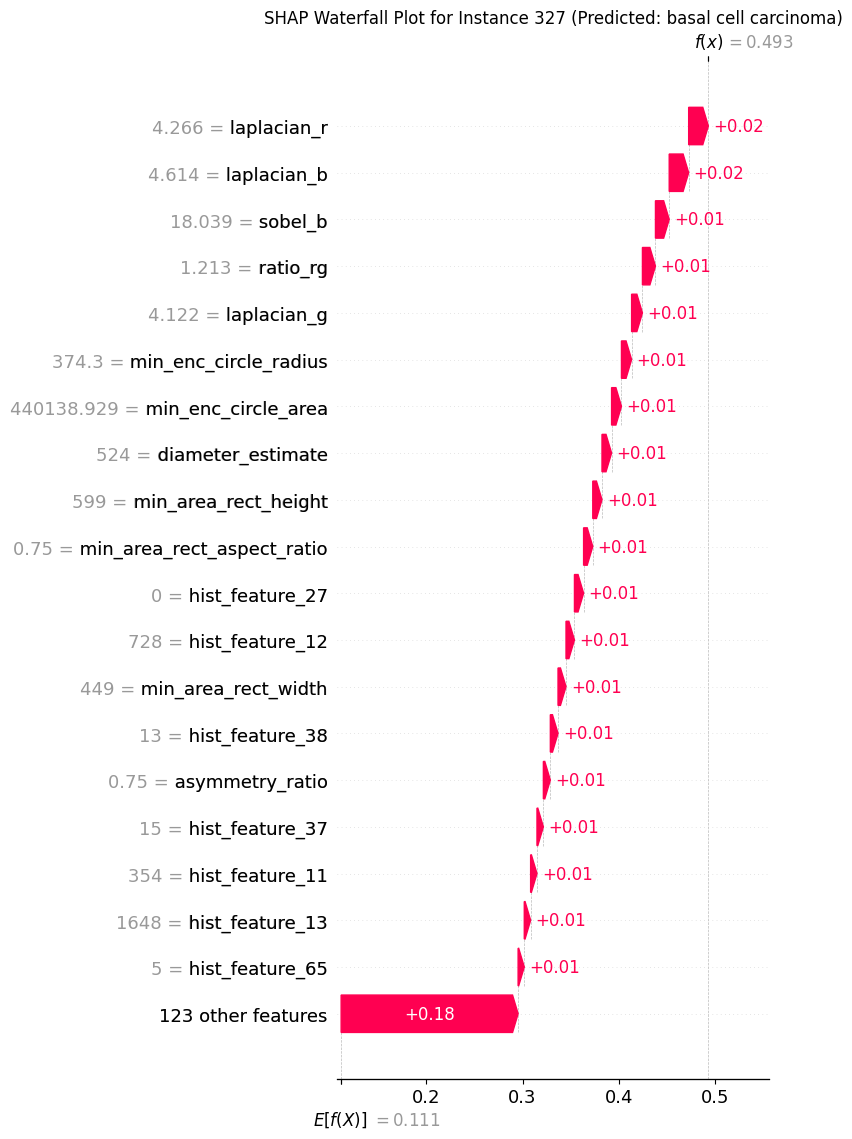

SHAP waterfall plot generated.


In [ ]:
import shap
import random

# Choose a random instance from the test set
instance_idx = random.randint(0, len(X_test) - 1)
X_test_instance = X_test.iloc[[instance_idx]]
y_test_instance = y_test.iloc[instance_idx]

print(f"Displaying SHAP waterfall plot for instance index: {instance_idx}")
print(f"True label for this instance: {CLASS_NAMES[y_test_instance]}")

# Re-initialize explainer with the best model (RandomForestClassifier)
shap_model = best_model.named_steps["rf"]
explainer = shap.TreeExplainer(shap_model)

# Get SHAP values for the selected instance
# We need to specify the output class if shap_vals is a list of arrays (multi-output)
# Let's visualize for the predicted class or a specific class (e.g., class 1: melanoma)

# Predict the class for the instance to show SHAP for the predicted class
predicted_class_idx = best_model.predict(X_test_instance)[0]
predicted_class_name = CLASS_NAMES[predicted_class_idx]

print(f"Predicted label for this instance: {predicted_class_name}")

# SHAP values for the predicted class
# If shap_list is a list of (n_samples, n_features) arrays (like in the notebook output)
# Ensure shap_list is available. If not, recompute it as in STEP 15.
if 'shap_list' not in locals():
    try:
        shap_exp  = explainer(X_test)
        shap_vals = shap_exp.values
    except:
        shap_vals = explainer.shap_values(X_test)

    #normalize to (n_samples, n_features, n_classes)
    if isinstance(shap_vals, np.ndarray) and shap_vals.ndim == 3:
        shap_list = [shap_vals[:, :, i] for i in range(9)]
    elif isinstance(shap_vals, list):
        shap_list = shap_vals


if isinstance(shap_list, list):
    shap_values_for_instance = shap_list[predicted_class_idx][instance_idx]
else:
    # If shap_vals is a (n_samples, n_features, n_classes) array
    shap_values_for_instance = shap_vals[instance_idx, :, predicted_class_idx]

# Create a SHAP Explanation object for the specific instance and predicted class
explanation = shap.Explanation(
    values=shap_values_for_instance,
    base_values=explainer.expected_value[predicted_class_idx], # Expected value for the predicted class
    data=X_test_instance.values[0], # Feature values for the instance
    feature_names=X_test.columns.tolist()
)

# Plot the waterfall plot
plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation, max_display=20, show=False)
plt.title(f"SHAP Waterfall Plot for Instance {instance_idx} (Predicted: {predicted_class_name})")
plt.tight_layout()
plt.show()

print("SHAP waterfall plot generated.")

### **SHAP summary plots by class**

The SHAP summary plots explain feature influence separately for each lesion class across the full test set. Each class gets its own plot, showing which features most strongly affect the model output for that class.

Features near the top of a SHAP summary plot have larger average effects. The position of each point shows whether the feature pushed the prediction higher or lower for that class, and the coloring shows whether the feature value was high or low.



SHAP done.
Shape per class: (472, 142)


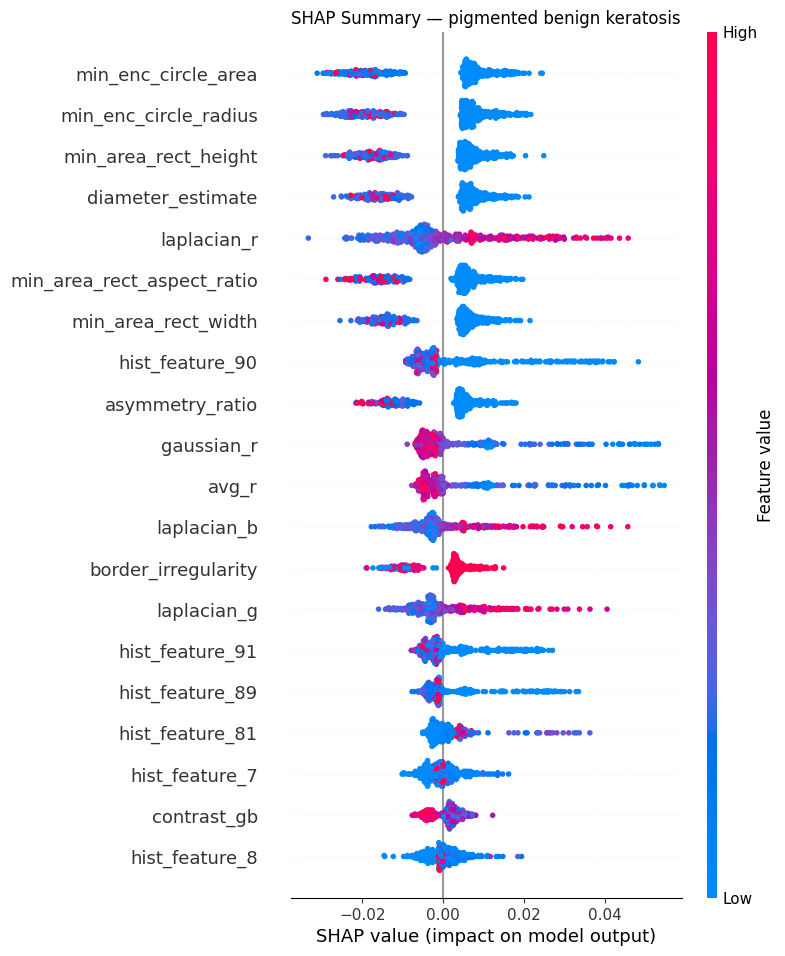

Saved: /content/drive/MyDrive/CAPSTONE PROJECT/Random Forest Models/shap/shap_summary_0_pigmented_benign_keratosis.png


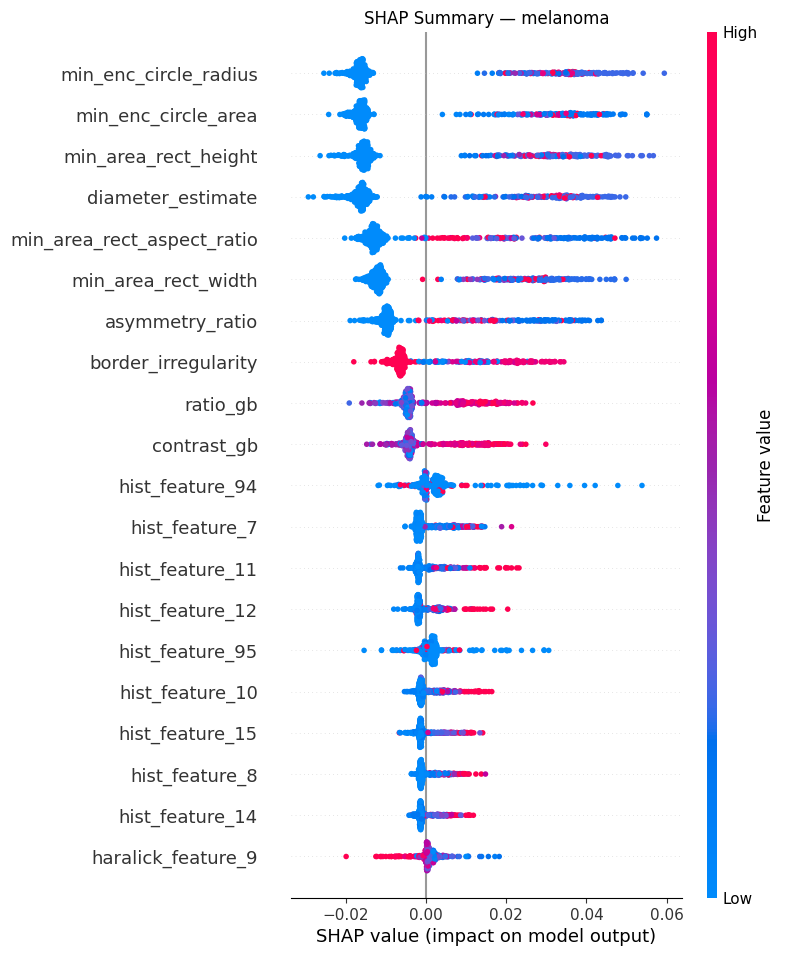

Saved: /content/drive/MyDrive/CAPSTONE PROJECT/Random Forest Models/shap/shap_summary_1_melanoma.png


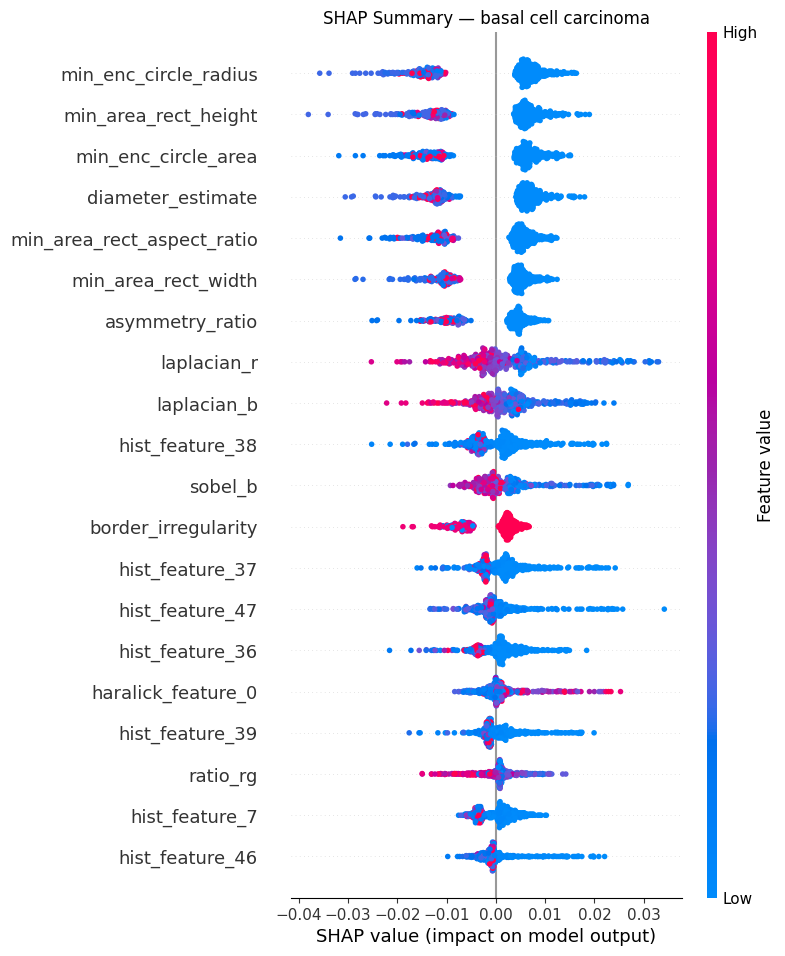

Saved: /content/drive/MyDrive/CAPSTONE PROJECT/Random Forest Models/shap/shap_summary_2_basal_cell_carcinoma.png


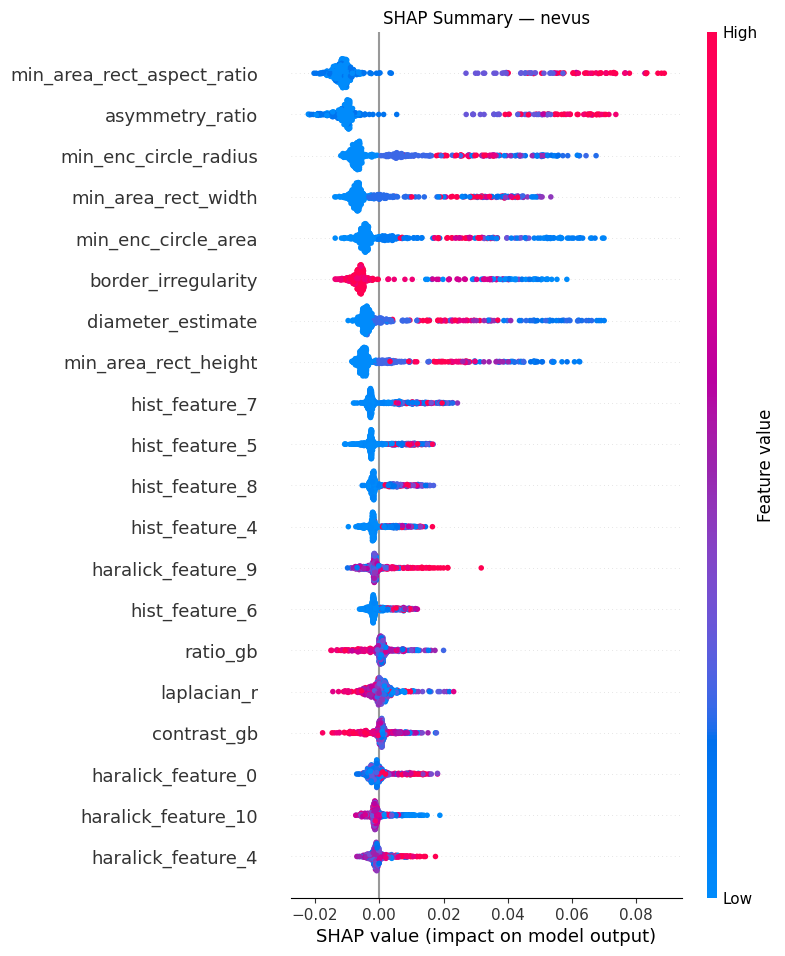

Saved: /content/drive/MyDrive/CAPSTONE PROJECT/Random Forest Models/shap/shap_summary_3_nevus.png


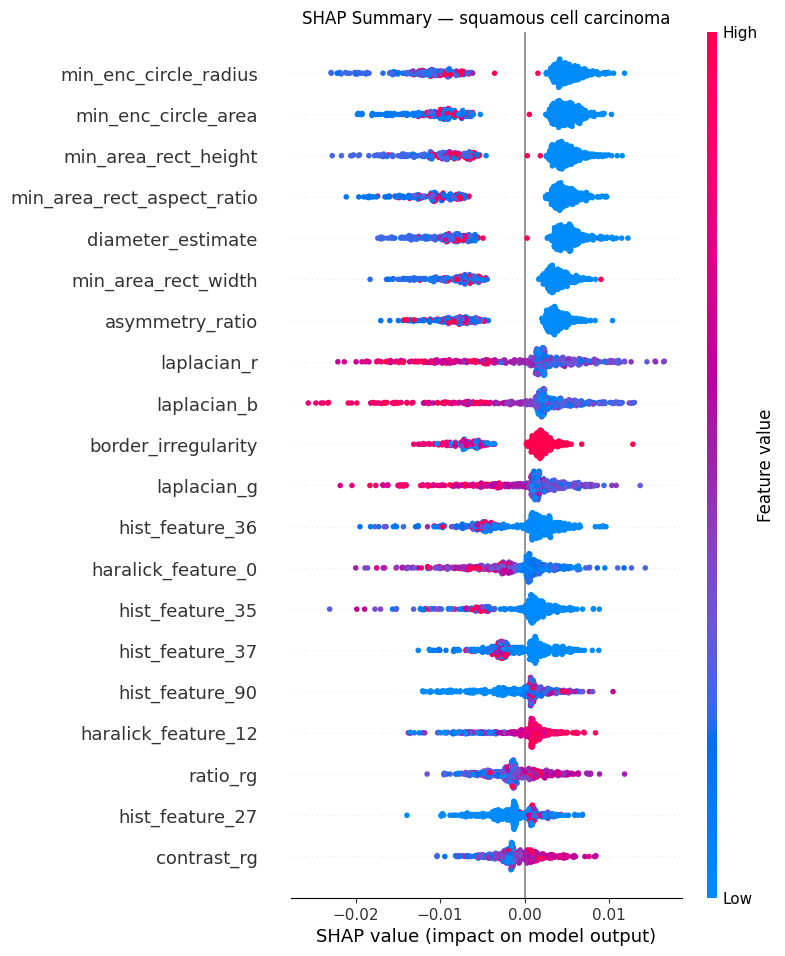

Saved: /content/drive/MyDrive/CAPSTONE PROJECT/Random Forest Models/shap/shap_summary_4_squamous_cell_carcinoma.png


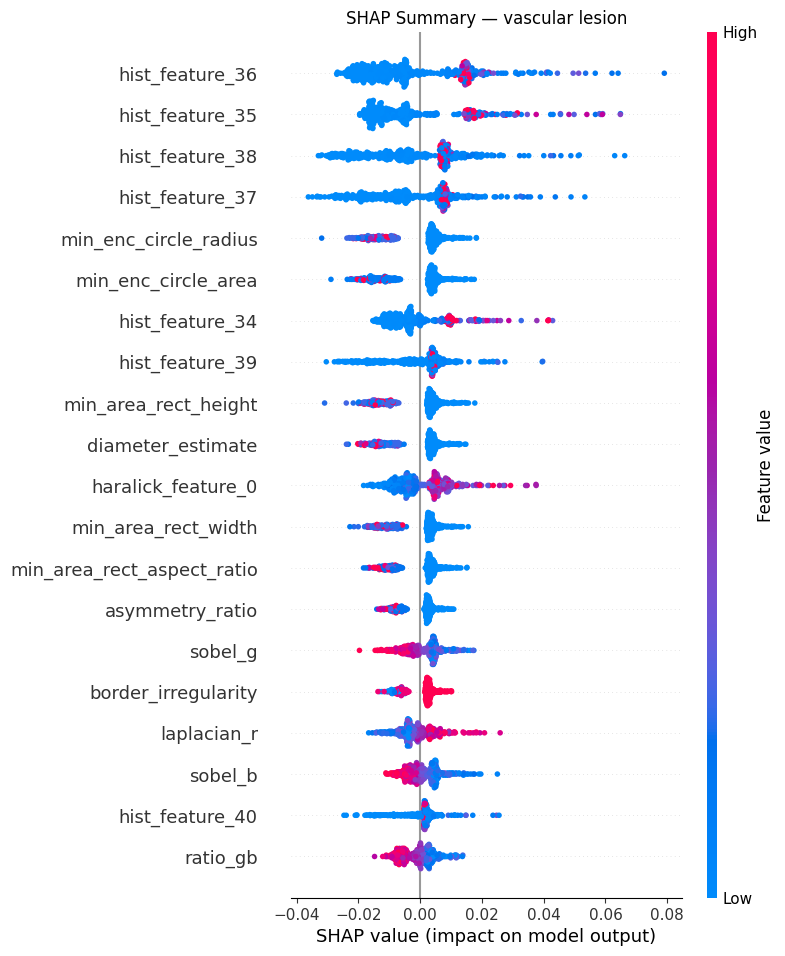

Saved: /content/drive/MyDrive/CAPSTONE PROJECT/Random Forest Models/shap/shap_summary_5_vascular_lesion.png


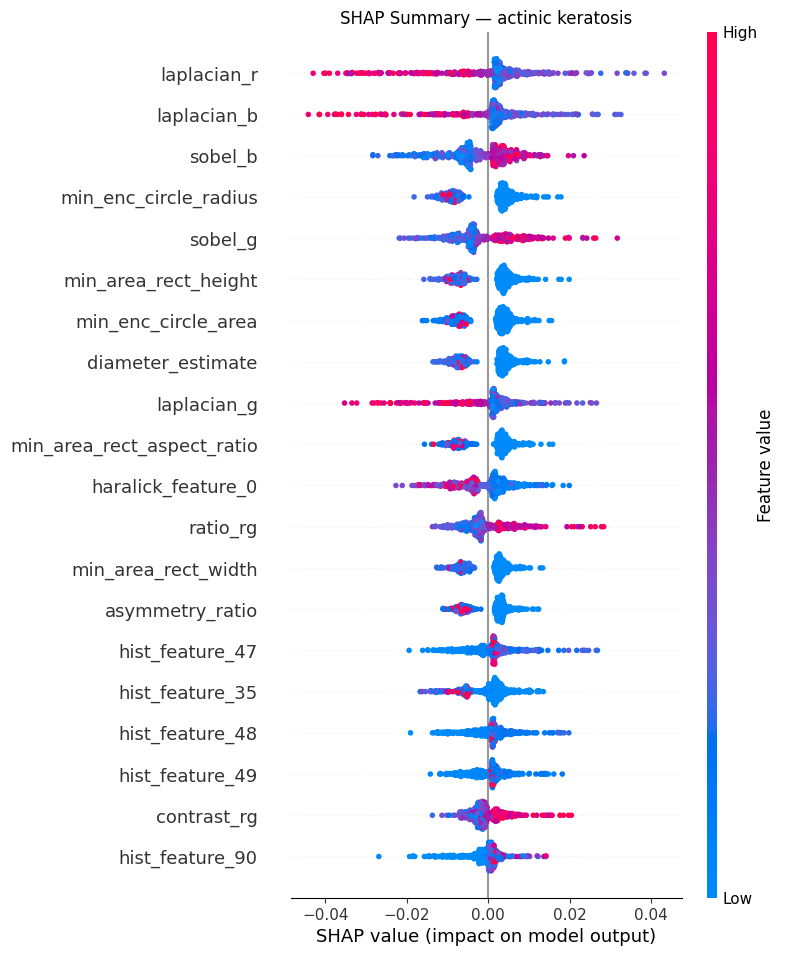

Saved: /content/drive/MyDrive/CAPSTONE PROJECT/Random Forest Models/shap/shap_summary_6_actinic_keratosis.png


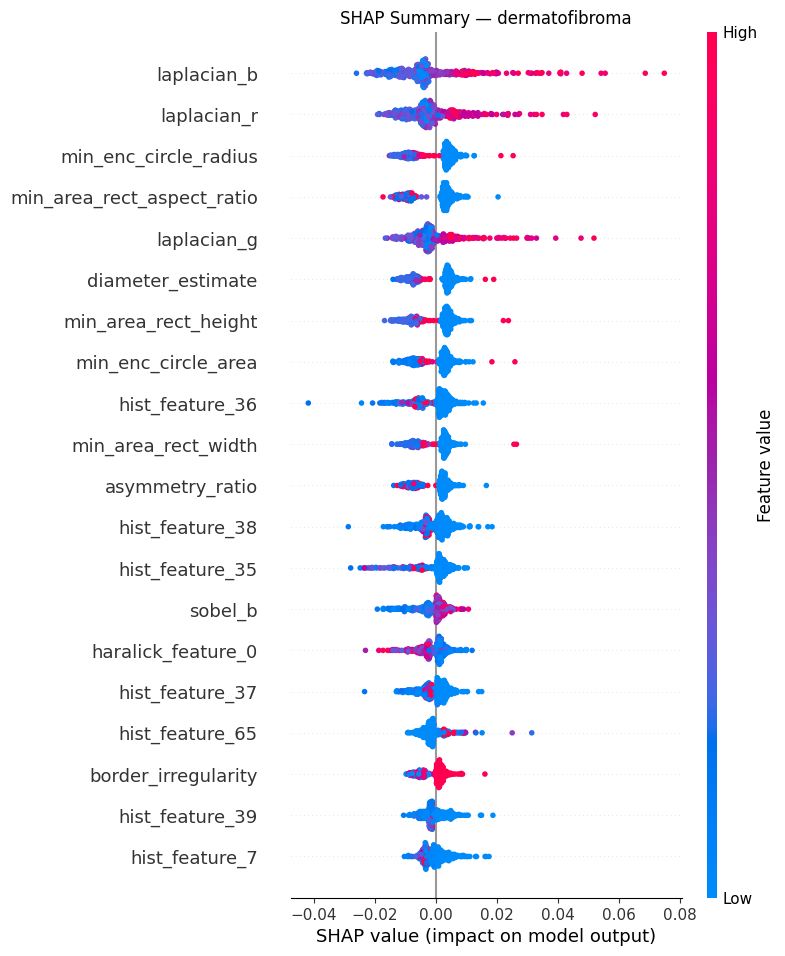

Saved: /content/drive/MyDrive/CAPSTONE PROJECT/Random Forest Models/shap/shap_summary_7_dermatofibroma.png


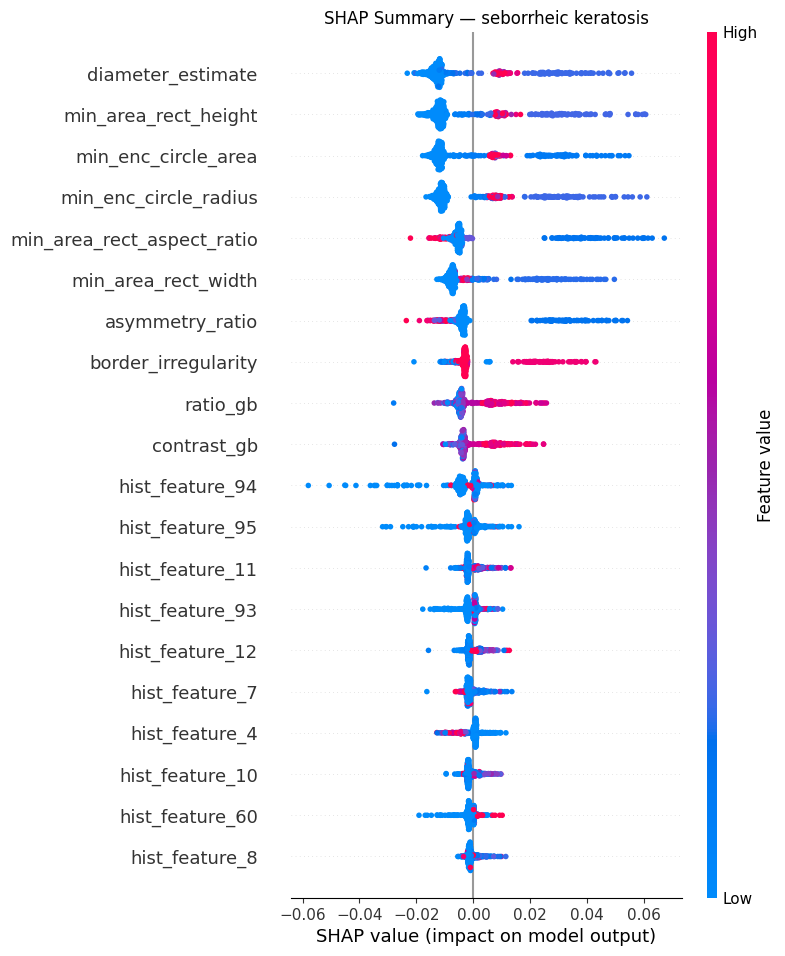

Saved: /content/drive/MyDrive/CAPSTONE PROJECT/Random Forest Models/shap/shap_summary_8_seborrheic_keratosis.png

Top 10 global SHAP features:


,feature,mean_abs_shap
0,min_enc_circle_radius,0.011303
1,min_enc_circle_area,0.010653
2,min_area_rect_height,0.010431
3,diameter_estimate,0.010319
4,min_area_rect_aspect_ratio,0.010047
5,min_area_rect_width,0.008684
6,asymmetry_ratio,0.008319
7,border_irregularity,0.005920
8,laplacian_r,0.005152
9,laplacian_b,0.004318


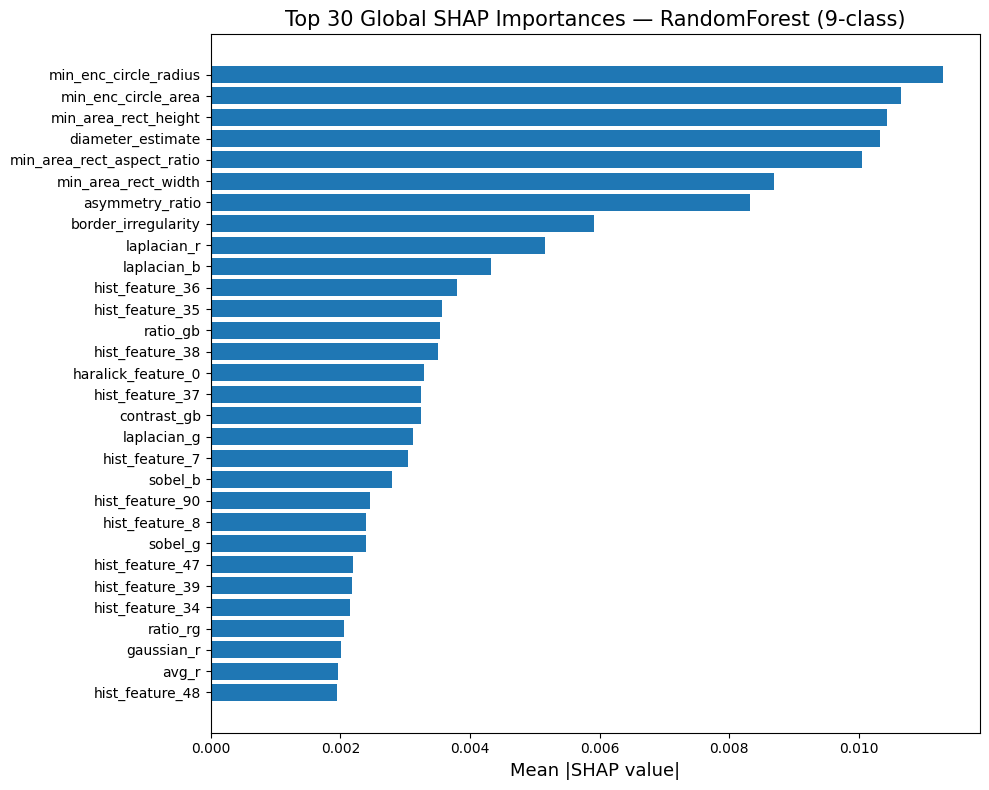

Saved global SHAP plot.


In [ ]:
#STEP 15: SHAP Analysis

import shap

SHAP_DIR = os.path.join(RESULTS_DIR, "shap")
os.makedirs(SHAP_DIR, exist_ok=True)

shap_model = best_model.named_steps["rf"]

explainer = shap.TreeExplainer(shap_model)

try:
    shap_exp  = explainer(X_test)
    shap_vals = shap_exp.values
except:
    shap_vals = explainer.shap_values(X_test)

#normalize to (n_samples, n_features, n_classes)
if isinstance(shap_vals, np.ndarray) and shap_vals.ndim == 3:
    shap_list = [shap_vals[:, :, i] for i in range(9)]
elif isinstance(shap_vals, list):
    shap_list = shap_vals

print("SHAP done.")
print("Shape per class:", shap_list[0].shape)

#summary plot per class
for i, cname in enumerate(CLASS_NAMES):
    plt.figure()
    shap.summary_plot(shap_list[i], X_test, show=False)
    plt.title(f"SHAP Summary — {cname}")
    out_path = os.path.join(SHAP_DIR, f"shap_summary_{i}_{cname.replace(' ','_')}.png")
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)

#global importance
mean_abs_shap = np.mean([np.abs(sv) for sv in shap_list], axis=(0, 1))

shap_global_df = pd.DataFrame({
    "feature"      : X_test.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

shap_global_df.to_csv(os.path.join(SHAP_DIR, "shap_global_importance.csv"), index=False)

print("\nTop 10 global SHAP features:")
display(shap_global_df.head(10))

#global bar plot
top_30 = shap_global_df.head(30).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(top_30["feature"], top_30["mean_abs_shap"])
plt.xlabel("Mean |SHAP value|", fontsize=13)
plt.title("Top 30 Global SHAP Importances — RandomForest (9-class)", fontsize=15) # Updated title
plt.tight_layout()
plt.savefig(os.path.join(SHAP_DIR, "shap_global_top30.png"), dpi=150)
plt.show()

print("Saved global SHAP plot.")

### **Global SHAP importance interpretation**

After generating class-specific SHAP plots, the notebook averages absolute SHAP values across classes and test examples to create a global SHAP importance ranking. The resulting bar chart shows which features had the largest overall influence on model predictions.

The Global SHAP importance plot shows that the Random Forest model relied most heavily on shape and size-related features when making predictions. The most important features were min_enc_circle_radius, min_enc_circle_area, min_area_rect_height, diameter_estimate, and min_area_rect_aspect_ratio, which all describe the lesion’s overall size, width, height, and shape. This suggests that the model found lesion geometry very useful for separating the nine classes.

Other important features included asymmetry_ratio and
border_irregularity, which relate to the lesion’s irregularity and structure. The model also used color and texture features such as laplacian_r, laplacian_b, histogram features, Sobel features, Gaussian features, and RGB ratio/contrast features.

Overall, this visualization shows that the model’s predictions were influenced by a mix of lesion shape, border irregularity, texture, and color patterns, with shape-based features being the strongest contributors.


### **SHAP force plot for one prediction**

The SHAP force plot is an interactive single-prediction explanation. It shows how individual features push the model output away from the baseline for the predicted class.

This visualization is similar in purpose to the waterfall plot, but it is designed for interactive notebook viewing. It is useful for presenting one selected test example and showing which features supported or opposed the model's predicted class.


In [ ]:
import shap
import random

# Choose a random instance from the test set for the force plot
instance_idx_fp = random.randint(0, len(X_test) - 1)
X_test_instance_fp = X_test.iloc[[instance_idx_fp]]
y_test_instance_fp = y_test.iloc[instance_idx_fp]

print(f"Displaying SHAP force plot for instance index: {instance_idx_fp}")
print(f"True label for this instance: {CLASS_NAMES[y_test_instance_fp]}")

# Reusing the explainer from previous SHAP analysis
# shap_model = best_model.named_steps["rf"]
# explainer = shap.TreeExplainer(shap_model)

# Predict the class for the instance to show SHAP for the predicted class
predicted_class_idx_fp = best_model.predict(X_test_instance_fp)[0]
predicted_class_name_fp = CLASS_NAMES[predicted_class_idx_fp]

print(f"Predicted label for this instance: {predicted_class_name_fp}")

# Get SHAP values for the selected instance for the predicted class
# This assumes shap_list is already available from previous SHAP analysis (STEP 15)
if isinstance(shap_list, list):
    shap_values_for_instance_fp = shap_list[predicted_class_idx_fp][instance_idx_fp]
else:
    # If shap_vals is a (n_samples, n_features, n_classes) array
    shap_values_for_instance_fp = shap_vals[instance_idx_fp, :, predicted_class_idx_fp]

# Get the base value (expected value) for the predicted class
base_value_fp = explainer.expected_value[predicted_class_idx_fp]

# Plot the force plot
# Note: shap.force_plot() is an interactive plot, so it might not display directly
# in some environments without specific renderer setup. It's often viewed in notebooks.
shap.initjs() # Initialize JavaScript for interactive plots

print(f"Generating force plot for predicted class: {predicted_class_name_fp}")
shap.force_plot(
    base_value_fp,
    shap_values_for_instance_fp,
    X_test_instance_fp.values[0],
    feature_names=X_test.columns.tolist()
)

print("SHAP force plot generated.")

Displaying SHAP force plot for instance index: 57
True label for this instance: melanoma
Predicted label for this instance: melanoma


Generating force plot for predicted class: melanoma
SHAP force plot generated.


### **Save predictions and review errors**

The final analysis step saves the test-set predictions, true labels, predicted labels, and class probabilities to a CSV file. It also creates a correct column to separate correct predictions from incorrect predictions.

The error-analysis table summarizes the most common true-label/predicted-label pairs among incorrect predictions. This is useful for identifying systematic weaknesses, such as classes that are repeatedly confused with each other.

In this notebook, the model correctly predicts **281** test examples and incorrectly predicts **191**. Reviewing the most common error pairs can guide future improvements, such as collecting more data for confused classes, adding stronger features, or trying models better suited for image classification.


In [ ]:
#STEP 16: Save Predictions + Error Analysis

results_df = X_test.copy()
results_df["true_label"] = y_test.values
results_df["pred_label"] = y_pred

#add probabilities for each class
prob_cols = [f"prob_{cname.replace(' ','_')}" for cname in CLASS_NAMES]
results_df[prob_cols] = y_proba

#save
save_path = os.path.join(RESULTS_DIR, "rf_9class_predictions.csv")
results_df.to_csv(save_path, index=False)
print("Saved predictions to:", save_path)

#correct vs incorrect
results_df["correct"] = results_df["true_label"] == results_df["pred_label"]

print("\nCorrect vs incorrect:")
print(results_df["correct"].value_counts())

#where is the model getting confused
confusion_breakdown = (
    results_df
    .loc[~results_df["correct"], ["true_label", "pred_label"]]
    .value_counts()
    .reset_index(name="count")
    .head(15)
)

print("\nTop 15 misclassifications:")
display(confusion_breakdown)

Saved predictions to: /content/drive/MyDrive/CAPSTONE PROJECT/Random Forest Models/rf_9class_predictions.csv

Correct vs incorrect:
correct
True     281
False    191
Name: count, dtype: int64

Top 15 misclassifications:


,true_label,pred_label,count
0,1,8,17
1,4,2,16
2,8,1,16
3,1,3,14
4,3,6,14
5,6,3,14
6,3,1,13
7,0,2,10
8,2,0,8
9,7,2,7
